# ml-1m Explanation Generation — `user_item_proto`

Generates TSNE plots, top-K items per prototype, and weight visualization for the best trial
of the `user_item_proto` hyperopt run on **ml-1m** (LEO5 SLURM job 6535752, 100/100 trials,
Val HR@10 0.6543 / Test HR@10 0.6246 — matches the RecSys'22 paper).

**Loading path (structured combo dir):** unlike `02_amazon_explanations.ipynb` (which predates
the combo-results format and reconstructs the model via `ExperimentAnalysis`), this run was
produced by `run_combo.py`, so it has a structured combo folder
(`best_model.pth` + `config.json` + `metadata.json`). We load it directly with the one-call
`utilities.explanations.loader.load_recsys_from_results_dir()`.

**Modular pipeline:** this notebook drives `utilities/explanations/` — the same pipeline
`run_combo.py` auto-invokes at the end of every explainable training run.

**Outputs → `Master/experiments/replication/explanations/ml-1m/` (per-dataset subfolder):**
- `tsne_item_prototypes.pdf`, `tsne_user_prototypes.pdf`
- `top_k_items_per_item_prototype.csv`, `top_k_items_per_user_prototype.csv`
- `weight_viz_user{uid}_user_side.pdf`, `weight_viz_user{uid}_item_side.pdf` (user_item_proto only)

> The checkpoint and the id-aligned `data/ml-1m/` splits were pulled from LEO5
> (`/scratch/c7031336/protomf_results/...` and `/scratch/c7031336/protomf_data/ml-1m`).
> Run this notebook inside the `protomf` conda env.

In [1]:
import os
import sys

import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, REPO_ROOT)

from utilities.explanations.loader import load_recsys_from_results_dir
from utilities.explanations.accessor import get_accessor
from utilities.explanations.explainers import REGISTERED_EXPLAINERS, ExplainCtx
from utilities.explanations.items_info import load_items_info

%matplotlib inline

## 1. Load the trained model from the structured combo dir

`load_recsys_from_results_dir` reads `config.json` + `metadata.json`, counts `n_users`/`n_items`
from `data/ml-1m/{user_ids,item_ids}.csv`, rebuilds the `RecSys` via `FeatureExtractorFactory`,
loads `best_model.pth`, and returns an `eval()`-mode model. `load_state_dict` succeeding is an
implicit check that the local data ids match what the checkpoint was trained on.

In [2]:
MODEL_TYPE = 'user_item_proto'
DATASET = 'ml-1m'

RESULTS_DIR = os.path.join(REPO_ROOT, 'Master', 'experiments', 'results',
                           'user_item_proto_ml-1m_s38210573')
OUTPUT_DIR = os.path.join(REPO_ROOT, 'Master', 'experiments', 'replication',
                          'explanations', 'ml-1m')
os.makedirs(OUTPUT_DIR, exist_ok=True)

model, config, metadata = load_recsys_from_results_dir(RESULTS_DIR)
model_type = metadata['model']
assert model_type == MODEL_TYPE, f"expected {MODEL_TYPE}, got {model_type}"
print(f"loaded {model_type} on {metadata['dataset']} (seed {metadata['seed']}, "
      f"{metadata['num_completed']}/{metadata['num_total']} trials)")

--- Building FeatureExtractor model ---
Built Embedding model 
- n_objects: 6034 
- embedding_dim: 73 
- max_norm: None
- only_positive: False
Built PrototypeEmbedding model 
- n_prototypes: 76 
- use_weight_matrix: False 
- sim_proto_weight: 1.7980209617727438 
- sim_batch_weight: 0.0017654765186204168 
- reg_proto_type: max 
- reg_batch_type: max 
- cosine_type: shifted 

--- Finished building FeatureExtractor model ---

--- Building FeatureExtractor model ---
Built Embedding model 
- n_objects: 6034 
- embedding_dim: 73 
- max_norm: None
- only_positive: False
Built Embeddingw model 
- out_dimension: 11 
- use_bias: False 

--- Finished building FeatureExtractor model ---

--- Building FeatureExtractor model ---
Built Embedding model 
- n_objects: 3125 
- embedding_dim: 73 
- max_norm: None
- only_positive: False
Built PrototypeEmbedding model 
- n_prototypes: 11 
- use_weight_matrix: False 
- sim_proto_weight: 1.6259454263434128 
- sim_batch_weight: 0.009407278448875614 
- reg_prot

## 2. Run the modular explainer pipeline

Three explainers are registered: `TSNEExplainer`, `TopKItemsExplainer`, `WeightVizExplainer`.
Each declares which model types it supports via `.supports(model_type)`. `user_item_proto`
(both user and item prototype branches) triggers all three.

`sample_users_for_weight_viz=[42]` decomposes the recommendation for user 42 into per-prototype
contributions on both the user and item side (matches the amazon notebook for cross-dataset
comparability; 0 ≤ 42 < 6034 users).

items_info: 3125 rows, columns=['item_id', 'item', 'title', 'year', 'genres']
  running 'tsne' ...


C:\Users\glaes\miniforge3\envs\protomf\lib\site-packages\sklearn\manifold\_t_sne.py:819: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(
C:\Users\glaes\miniforge3\envs\protomf\lib\site-packages\sklearn\manifold\_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


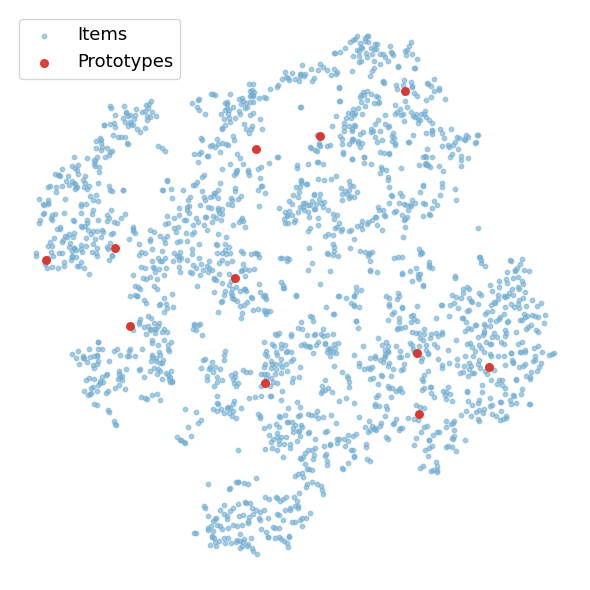

C:\Users\glaes\miniforge3\envs\protomf\lib\site-packages\sklearn\manifold\_t_sne.py:819: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(
C:\Users\glaes\miniforge3\envs\protomf\lib\site-packages\sklearn\manifold\_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


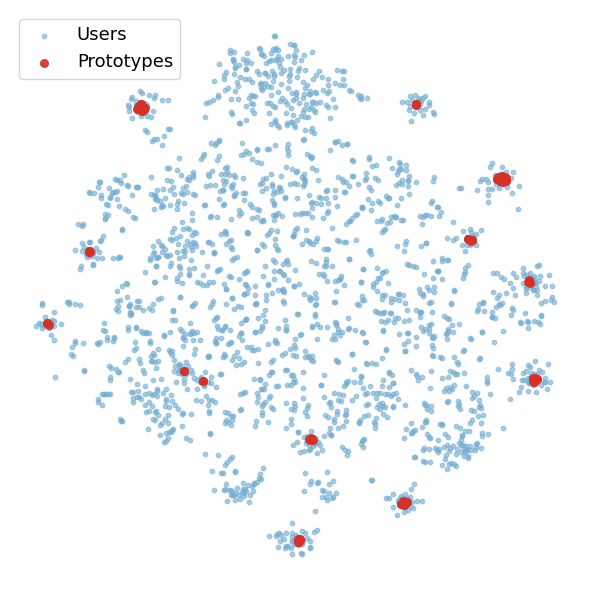

  running 'top_k_items' ...
  running 'weight_viz' ...



Done → C:\Users\glaes\Desktop\github\Prototype-Based-Explanations-for-Interpretable-Fashion-Recommendations\Master\experiments\replication\explanations\ml-1m
  top_k_items_per_item_prototype.csv
  top_k_items_per_user_prototype.csv
  tsne_item_prototypes.pdf
  tsne_user_prototypes.pdf
  weight_viz_user42_item_side.pdf
  weight_viz_user42_user_side.pdf


In [3]:
accessor = get_accessor(model_type, model)
items_info = load_items_info(DATASET)
print(f"items_info: {len(items_info)} rows, columns={list(items_info.columns)}")

ctx = ExplainCtx(
    accessor=accessor,
    items_info=items_info,
    output_dir=OUTPUT_DIR,
    tsne_sample_size=2000,
    top_k=10,
    sample_users_for_weight_viz=[42],
)

for explainer in REGISTERED_EXPLAINERS:
    if not explainer.supports(model_type):
        continue
    print(f"  running '{explainer.name}' ...")
    try:
        explainer.run(ctx)
    except Exception as e:
        print(f"    ⚠ '{explainer.name}' failed: {e!r}")

print(f"\nDone → {OUTPUT_DIR}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

## 3. Inspect outputs

TSNE and weight-viz PDFs are best opened externally. The top-K CSVs are tabular — show them
inline below. The `item` column is the original MovieLens movieId (join with `movies.dat` for
titles/genres if richer interpretation is needed).

In [4]:
item_proto_csv = os.path.join(OUTPUT_DIR, 'top_k_items_per_item_prototype.csv')
df_item = pd.read_csv(item_proto_csv)
print(f"Item prototypes: {df_item['prototype'].nunique()} × top-{ctx.top_k} items each\n")
df_item.groupby('prototype').head(5)

Item prototypes: 11 × top-10 items each



,item_id,item,title,year,genres,item weight,prototype
0,1310,3004,"Bachelor, The (1999)",1999,Comedy|Romance,1.999939,0
1,1919,491,"Man Without a Face, The (1993)",1993,Drama,1.996819,0
2,917,605,One Fine Day (1996),1996,Drama|Romance,1.967737,0
3,1222,140,Up Close and Personal (1996),1996,Drama|Romance,1.928719,0
4,294,3259,Far and Away (1992),1992,Drama|Romance,1.922866,0
10,1658,3282,Different for Girls (1996),1996,Comedy,1.999842,1
11,1539,2820,Hamlet (1964),1964,Drama,1.999330,1
12,2211,2610,Three Seasons (1999),1999,Drama,1.967738,1
13,2381,263,Ladybird Ladybird (1994),1994,Drama,1.962581,1
14,2015,3567,Bossa Nova (1999),1999,Comedy,1.947721,1


In [5]:
user_proto_csv = os.path.join(OUTPUT_DIR, 'top_k_items_per_user_prototype.csv')
df_user = pd.read_csv(user_proto_csv)
print(f"User prototypes: {df_user['prototype'].nunique()} × top-{ctx.top_k} items each")
print("(Each user prototype is interpreted by the items maximally aligned with it.)\n")
df_user.groupby('prototype').head(5)

User prototypes: 76 × top-10 items each
(Each user prototype is interpreted by the items maximally aligned with it.)



,item_id,item,title,year,genres,item weight,prototype
0,197,1089,Reservoir Dogs (1992),1992,Crime|Thriller,0.324312,0
1,336,778,Trainspotting (1996),1996,Drama,0.316250,0
2,163,296,Pulp Fiction (1994),1994,Crime|Drama,0.301225,0
3,44,1246,Dead Poets Society (1989),1989,Drama,0.281585,0
4,1026,431,Carlito's Way (1993),1993,Crime|Drama,0.270402,0
...,...,...,...,...,...,...,...
750,599,2694,Big Daddy (1999),1999,Comedy,0.240642,75
751,215,2908,Boys Don't Cry (1999),1999,Drama,0.204072,75
752,1047,2485,She's All That (1999),1999,Comedy|Romance,0.195594,75
753,586,2706,American Pie (1999),1999,Comedy,0.186463,75


In [6]:
pdfs = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.pdf')]
print('PDF outputs (open externally):')
for f in sorted(pdfs):
    print(f"  {os.path.join(OUTPUT_DIR, f)}")

PDF outputs (open externally):
  C:\Users\glaes\Desktop\github\Prototype-Based-Explanations-for-Interpretable-Fashion-Recommendations\Master\experiments\replication\explanations\ml-1m\tsne_item_prototypes.pdf
  C:\Users\glaes\Desktop\github\Prototype-Based-Explanations-for-Interpretable-Fashion-Recommendations\Master\experiments\replication\explanations\ml-1m\tsne_user_prototypes.pdf
  C:\Users\glaes\Desktop\github\Prototype-Based-Explanations-for-Interpretable-Fashion-Recommendations\Master\experiments\replication\explanations\ml-1m\weight_viz_user42_item_side.pdf
  C:\Users\glaes\Desktop\github\Prototype-Based-Explanations-for-Interpretable-Fashion-Recommendations\Master\experiments\replication\explanations\ml-1m\weight_viz_user42_user_side.pdf
